In [223]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys

sys.path.append(
    "/home/ae19663/artiq"
)  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".


folder_directory = (
    "../results/2025-09-10/19/"  # Example directory path, adjust as needed
)
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze, this file consisit of many runs of of particular scan parameter if you have multiple runs
particular_directory = (
    folder_directory + "000010466-AbsorptionImageExpFrag.h5"
)  # Example file path, adjust as needed


class EXTRACTOR():
    def __init__(self, artiq_folder_directory, folder_directory, particular_directory):
        self.artiq_folder_directory = artiq_folder_directory
        self.folder_directory = folder_directory
        self.particular_directory = particular_directory
        self.files_directory = EXTRACTOR.sorted_files(folder_directory)

    def list_h5_files(self):
        """
        List all .h5 files in the artiq folder directory.
        """
        file_names = os.listdir(self.folder_directory)
        # calculate how many files are there in the directory
        num_files = len(file_names)
        print(f"Number of files in the directory: {num_files}")
        return [f for f in file_names if f.endswith(".h5")], num_files

    def sorted_files(directory):
        """
        Sort files in the given directory based on the numeric part of their names.
        """
        files = os.listdir(directory)
        file_num = []
        file_name = []

        for i in files:
            # Split the file name into two parts and sort by the numeric part
            file_num.append(i.split("-")[0])
            file_name.append(i.split("-")[1])

        # Sort the files based on the numeric part
        file_num, file_name = zip(*sorted(zip(file_num, file_name)))

        # Recombine the file number and file name into a single list
        sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

        # Directory list for the files using the sorted file names
        files_directory = [
            os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
        ]

        # Example usage:
        # directory = "../results/2025-07-08/21/"
        # files_directory = sorted_files(directory)

        return files_directory

    def get_override_args(file_directory, hide_defaults=True):
        vals = {}

        f1 = h5py.File(file_directory, "r")
        args = pyon.decode(f1["expid"][()])["arguments"]
        for k, v in args.items():
            if k == "ndscan_params":
                params = pyon.decode(args["ndscan_params"])
                overrides = params["overrides"]
                for k, v in overrides.items():
                    spec = params["schemata"][k]["spec"]
                    val = v[0]["value"]
                    default = type(val)(params["schemata"][k]["default"])
                    if hide_defaults and val == default:
                        continue
                    vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
            else:
                vals[k] = [v, ""]
        return vals

    vals = get_override_args(particular_directory, hide_defaults=False)

    def args_names_and_vals(vals):
        # Print arguments names and their values
        args_names = []
        args_vals = []
        for k, (v, unit) in vals.items():
            # print(f"{k} = {v} {unit}")
            args_names.append(k)
            args_vals.append(v)
        return args_names, args_vals

    files_directory = sorted_files(folder_directory)
    # print(files_directory)

    matching_args = []
    for i in range(len(files_directory)):
        #print(f"File {i + 1}: {files_directory[i]}")
        vals1 = get_override_args(files_directory[i])
        args_name1, args_val1 = args_names_and_vals(vals1)
        for j in range(len(files_directory)):
            vals2 = get_override_args(files_directory[j])
            args_name2, args_val2 = args_names_and_vals(vals2)
            if args_name1 == args_name2:
                # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
                matching_args.append((files_directory[i], files_directory[j]))
            else:
                # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
                pass

    # plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
    def plot_absorption_image(file_directory, run_number):
        f1 = h5py.File(file_directory, "r")
        if run_number == 0:
            a = 0
        else:
            a = run_number * 3
        image_0 = "Images.All" + "." + str(a)
        image_1 = "Images.All" + "." + str(a + 1)
        image_2 = "Images.All" + "." + str(a + 2)

        absimg = AbsImage(
            data=f1["datasets"][image_0][()],
            ref=f1["datasets"][image_1][()],
            bg=f1["datasets"][image_2][()],
            magnification=0.25,  # Set default magnification
        )
        absimg.plot()
        #plt.show()

    scan_number = 5  # Example scan number, adjust as needed

    #plot_absorption_image(particular_directory, scan_number)
    # Extracting the values and the units from the files
    f1 = h5py.File(files_directory[0], "r")
    a = f1["datasets"]

    # Extracting the values and the units from the files
    f1 = h5py.File(files_directory[0], "r")
    a = f1["datasets"]
    #print(f"Keys in the datasets: {list(a.keys())}")

file_number=2

class Extractor_file(EXTRACTOR):
    def __init__(self, file_number):
        self.particular_directory = particular_directory
        self.file_number = file_number

        if self.file_number < 0 or self.file_number >= len(self.files_directory):
            raise ValueError(
                f"File number {self.file_number} is out of range. Please choose a number between 0 and {len(self.files_directory) - 1}."
            )

        # Extracting the values and the units from the files
        f1 = h5py.File(self.files_directory[self.file_number], "r")
        # extract file name and run number from the file path

        file_name = os.path.basename(self.files_directory[self.file_number])
        run_number = int(file_name.split("-")[0])
        c = "ndscan.rid_" + str(run_number) + ".points.channel_info"
        d = "ndscan.rid_" + str(run_number) + ".points.axis_0"

        import re  # Ensure re is imported

        a = f1["datasets"][c][()]

        peakx = []
        peaky = []
        centroidx = []
        centroidy = []
        wavelength = []
        atom_number = []
        A = []
        sx = []
        sy = []
        x0 = []
        y0 = []

        for i in range(a.shape[0]):
            # decode if bytes, otherwise use as is
            if isinstance(a[i], bytes):
                decoded = a[i].decode("utf-8")
                lines = decoded.split("\n")
            else:
                lines = a[i]

            for line in lines:
                b = line.strip(",").split(":")
                key = b[0].strip().strip('"')
                if key == "wavelength":
                    wavelength.append(float(b[1]))
                elif key == "atom_number":
                    atom_number.append(float(b[1]))
                elif key == "peak_pixel":  # Assuming this is a key for peak pixels
                    # extract numbers from tuple string
                    tuple_str = ":".join(b[1:]).strip()
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
                    if len(nums) >= 3:
                        peakx.append(float(nums[0]))
                        peaky.append(float(nums[1]))
                        # If you want the third value, use float(nums[2])
                    # else skip or handle error
                elif key == "centroid_pixel":  # Assuming this is a key for centroid pixels
                    tuple_str = ":".join(b[1:]).strip()
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
                    if len(nums) >= 3:
                        centroidx.append(float(nums[0]))
                        centroidy.append(float(nums[1]))
                        # If you want the third value, use float(nums[2])
                elif key == "best_values_pixel":  # Assuming this is a key for some values
                    # Extract dictionary from line
                    match = re.search(r"\{(.+?)\}", line)
                    if match:
                        dict_str = match.group(1)
                        items = dict_str.split(",")
                        for item in items:
                            item = item.strip()
                            if ":" in item:
                                key_part, value_part = item.split(":", 1)
                                key_item = key_part.strip().strip("'")
                                value_str = value_part.strip()
                                # Convert to float or int
                                if "." in value_str or "e" in value_str:
                                    value = float(value_str)
                                else:
                                    value = int(value_str)
                                # Append to the correct list
                                if key_item == "A":
                                    A.append(value)
                                elif key_item == "x0":
                                    x0.append(value)
                                elif key_item == "y0":
                                    y0.append(value)
                                elif key_item == "sx":
                                    sx.append(value)
                                elif key_item == "sy":
                                    sy.append(value)
                                elif key_item == "theta":
                                    if not hasattr(self, "theta"):
                                        self.theta = []
                                    self.theta.append(value)
                                elif key_item == "z0":
                                    if not hasattr(self, "z0"):
                                        self.z0 = []
                                    self.z0.append(value)

        # extract scan parameters from the file
        scan_params = f1["datasets"][d][()]
        # add more decimal places to scan params

        #print(scan_params)

        # list contents in datasets
        datasets = list(f1["datasets"].keys())
        #print("Datasets in the file:", datasets)

        # print the extracted values
        #print("Wavelength:", wavelength)
        #print("Atom Number:", atom_number)
        #print("Peak X:", peakx)
        #print("Peak Y:", peaky)
        #print("Centroid X:", centroidx)
        #print("Centroid Y:", centroidy)
        #print("A:", A)
        #print("Sx:", sx)
        #print("Sy:", sy)
        #print("X0:", x0)
        #print("Y0:", y0)

        # store everything in the csv file also scan parameters
        self.data = {
            "wavelength": wavelength,
            "atom_number": atom_number,
            "peakx": peakx,
            "peaky": peaky,
            "centroidx": centroidx,
            "centroidy": centroidy,
            "A": A,
            "sx": sx,
            "sy": sy,
            "x0": x0,
            "y0": y0,
            "scan_params": scan_params,
        }

        self.datasets = datasets

Files in directory: ['000010468-AbsorptionImageExpFrag.h5', '000010471-AbsorptionImageExpFrag.h5', '000010472-AbsorptionImageExpFrag.h5', '000010473-AbsorptionImageExpFrag.h5', '000010478-AbsorptionImageExpFrag.h5', '000010480-AbsorptionImageExpFrag.h5', '000010470-AbsorptionImageExpFrag.h5', '000010477-AbsorptionImageExpFrag.h5', '000010475-AbsorptionImageExpFrag.h5', '000010474-AbsorptionImageExpFrag.h5', '000010466-AbsorptionImageExpFrag.h5', '000010479-AbsorptionImageExpFrag.h5', '000010476-AbsorptionImageExpFrag.h5', '000010469-AbsorptionImageExpFrag.h5', '000010467-AbsorptionImageExpFrag.h5']


In [224]:
# exposure time
exposure_time = 0.03e-3
scaling_factor = 25.52 * 1e-6

set=5, #number of files in the set
range_1 = 11   #starting file number
range_2 = 15   #ending file number


Peak_x_set = []
Peak_y_set = []
Centroid_x_set = []
Centroid_y_set = []
A_set = []
Sx_set = []
Sy_set = []
X0_set = []
Y0_set = []
Wavelength_set = []
Atom_number_set = []
Scan_params_set = []


#go to all the files in the set see if scan parameters are same or not
# if same then extract the data and store in the lists
# if not same then print the message and stop the program	

for i in range(range_1, range_2):
	try:
		Extractor_file_instance = Extractor_file(i)
		dataset = Extractor_file_instance.data
		scan_params = dataset['scan_params']
		if scan_params.all() == Extractor_file_instance.data['scan_params'].all():
			# Extract data and store in lists
			Peak_x_set.append(dataset['peakx'])
			Peak_y_set.append(dataset['peaky'])
			Centroid_x_set.append(dataset['centroidx'])
			Centroid_y_set.append(dataset['centroidy'])
			A_set.append(dataset['A'])
			Sx_set.append(dataset['sx'])
			Sy_set.append(dataset['sy'])
			X0_set.append(dataset['x0'])
			Y0_set.append(dataset['y0'])
			Wavelength_set.append(dataset['wavelength'])
			Atom_number_set.append(dataset['atom_number'])
			Scan_params_set.append(dataset['scan_params'])
		else:
			print(f"Scan parameters do not match for file {i}. Stopping extraction.")
			break

	except KeyError as e:
		print(f"KeyError: {e}")
		print("The required dataset does not exist in the selected file. Please check the file or choose a different file_number.")


# Convert lists to numpy arrays for easier manipulation
Peak_x_set = np.array(Peak_x_set)
Peak_y_set = np.array(Peak_y_set)
Centroid_x_set = np.array(Centroid_x_set)
Centroid_y_set = np.array(Centroid_y_set)
A_set = np.array(A_set)
Sx_set = np.array(Sx_set)
Sy_set = np.array(Sy_set)
X0_set = np.array(X0_set)
Y0_set = np.array(Y0_set)
Wavelength_set = np.array(Wavelength_set)
Atom_number_set = np.array(Atom_number_set)
Scan_params_set = np.array(Scan_params_set)

print("Data extraction complete.")
#print(Scan_params_set)


for i in range(len(Scan_params_set)):
	# sort each array in increasing order and then sort all the other arrays based on the scan parameters
	sorted_indices = np.argsort(Scan_params_set[i])
	Scan_params_set[i] = Scan_params_set[i][sorted_indices]
	Peak_x_set[i] = Peak_x_set[i][sorted_indices]
	Peak_y_set[i] = Peak_y_set[i][sorted_indices]
	Centroid_x_set[i] = Centroid_x_set[i][sorted_indices]
	Centroid_y_set[i] = Centroid_y_set[i][sorted_indices]
	A_set[i] = A_set[i][sorted_indices]
	Sx_set[i] = Sx_set[i][sorted_indices]
	Sy_set[i] = Sy_set[i][sorted_indices]
	X0_set[i] = X0_set[i][sorted_indices]
	Y0_set[i] = Y0_set[i][sorted_indices]
	Wavelength_set[i] = Wavelength_set[i][sorted_indices]
	Atom_number_set[i] = Atom_number_set[i][sorted_indices]

#print(Peak_x_set)
print(Sx_set)
#print(Sy_set)
# Change units of scan params in ms and add exposure time to it
for i in range(len(Scan_params_set)):
	Scan_params_set[i] = Scan_params_set[i] + exposure_time

#in 2d find means and std of each column in the 2D array
def mean_std(dataset):
	means = []
	stds = []
	for j in range(dataset.shape[1]):
		means.append(np.mean(dataset[:,j]))
		stds.append(np.std(dataset[:,j]))
	return means, stds


#save all the data in the csv file with date and timestamp and folder name and which files used in the path i will give it later

data_dict = {
	'Scan_params_set': Scan_params_set.flatten(),
	'Peak_x_set': Peak_x_set.flatten(),
	'Peak_y_set': Peak_y_set.flatten(),
	'Centroid_x_set': Centroid_x_set.flatten(),
	'Centroid_y_set': Centroid_y_set.flatten(),
	'A_set': A_set.flatten(),
	'Sx_set': Sx_set.flatten(),
	'Sy_set': Sy_set.flatten(),
	'X0_set': X0_set.flatten(),
	'Y0_set': Y0_set.flatten(),
	'Wavelength_set': Wavelength_set.flatten(),
	'Atom_number_set': Atom_number_set.flatten()
}



Data extraction complete.
[[119.45195501  15.60504028  17.41676281  20.97096213  24.27591947
   28.45118439  32.31825065  31.94095061  35.30519547]
 [121.27001564  14.80189585  17.60022383  20.92043533  24.49020628
   28.40387528  32.26271425  36.2503074   40.33659956]
 [116.87899944  15.45088534  17.83697898  22.31612636  24.55877446
   27.86287914  35.51576822  36.10844469  41.19733627]
 [122.92047879  16.02519332  17.67895792  20.61366297  24.6765902
   31.20422557  31.21883281  35.45676627  40.02764736]]


Pixel data: [673.25 666.75 666.25 659.75 657.5  655.75 633.75 624.75 619.25]
TOF data: [0.00103 0.00303 0.00503 0.00703 0.00903 0.01103 0.01303 0.01503 0.01703]
Sorted TOF data: [0.00103 0.00303 0.00503 0.00703 0.00903 0.01103 0.01303 0.01503 0.01703]
Sorted Pixel data: [673.25 666.75 666.25 659.75 657.5  655.75 633.75 624.75 619.25]
y0 = -20.4900017 ± 2.1440466 pixels
s = 25.9032734 ± 2.0261412 μm


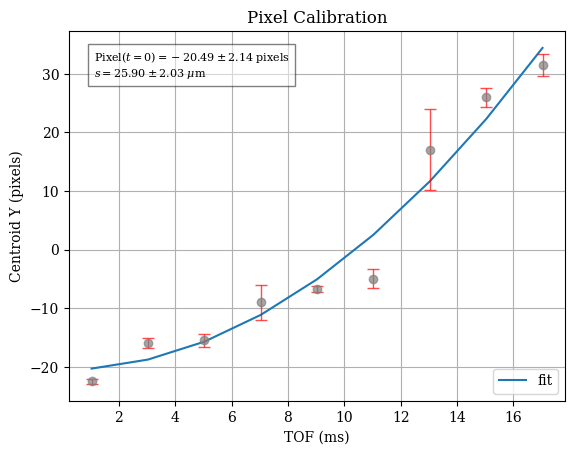

In [225]:
# pixel calibration fit
g = 9.81  # m/s^2, gravitational acceleration

peakx_mean=mean_std(Peak_x_set)[0]
peakx_std=mean_std(Peak_x_set)[1]

try:
    t_data = Scan_params_set[0]  # TOF data, assuming all sets have the same scan parameters
except IndexError:
    print("Error: Scan_params_set is empty. Please check the data extraction process.")
    t_data = []

pixel_number_vertical_data = np.array(peakx_mean)  # Pixel data, using peakx as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)


# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)

pixel_data_sorted = -(pixel_data_sorted - np.mean(pixel_data_sorted))


def model_pixel_calibration(t, y0, s):
    return y0 + (1 / 2) * t**2 * g / s


# Initial GUESS
y0_initial = 0.0
s_initial = 40e-6



# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    t_data_sorted,
    pixel_data_sorted,
    p0=[y0_initial, s_initial],
)
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit * 1e6:.7f} ± {s_err * 1e6:.7f} μm")


# Plot pixel calibration
#plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="data")
plt.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    label="fit",
)
#make the point size transparent

plt.xlabel("TOF (ms)", fontdict={"fontsize": 10, "family": "serif"})
plt.ylabel("Centroid Y (pixels)", fontdict={"fontsize": 10, "family": "serif"})
plt.legend()
plt.grid(True)

fit_text = (
    r"$\mathrm{Pixel}(t=0) = "
    + f"{y0_fit:.2f} \pm {y0_err:.2f}"
    + r"\ \mathrm{{pixels}}$"
    + "\n"
    + r"$s = "
    + f"{s_fit * 1e6:.2f} \pm {s_err * 1e6:.2f}"
    + r"\ \mu\mathrm{m}$"
)

plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
    fontdict={"fontsize": 8, "family": "serif"}
)

plt.errorbar(
    t_data_sorted * 1e3,
    pixel_data_sorted,
    yerr=peakx_std,
    fmt="o",
    color="gray",
    ecolor="red",
    elinewidth=1,
    capsize=4, alpha=0.7
)

#plt.tight_layout()
plt.title("Pixel Calibration", fontdict={"fontsize": 12, "family": "serif"})
plt.show()




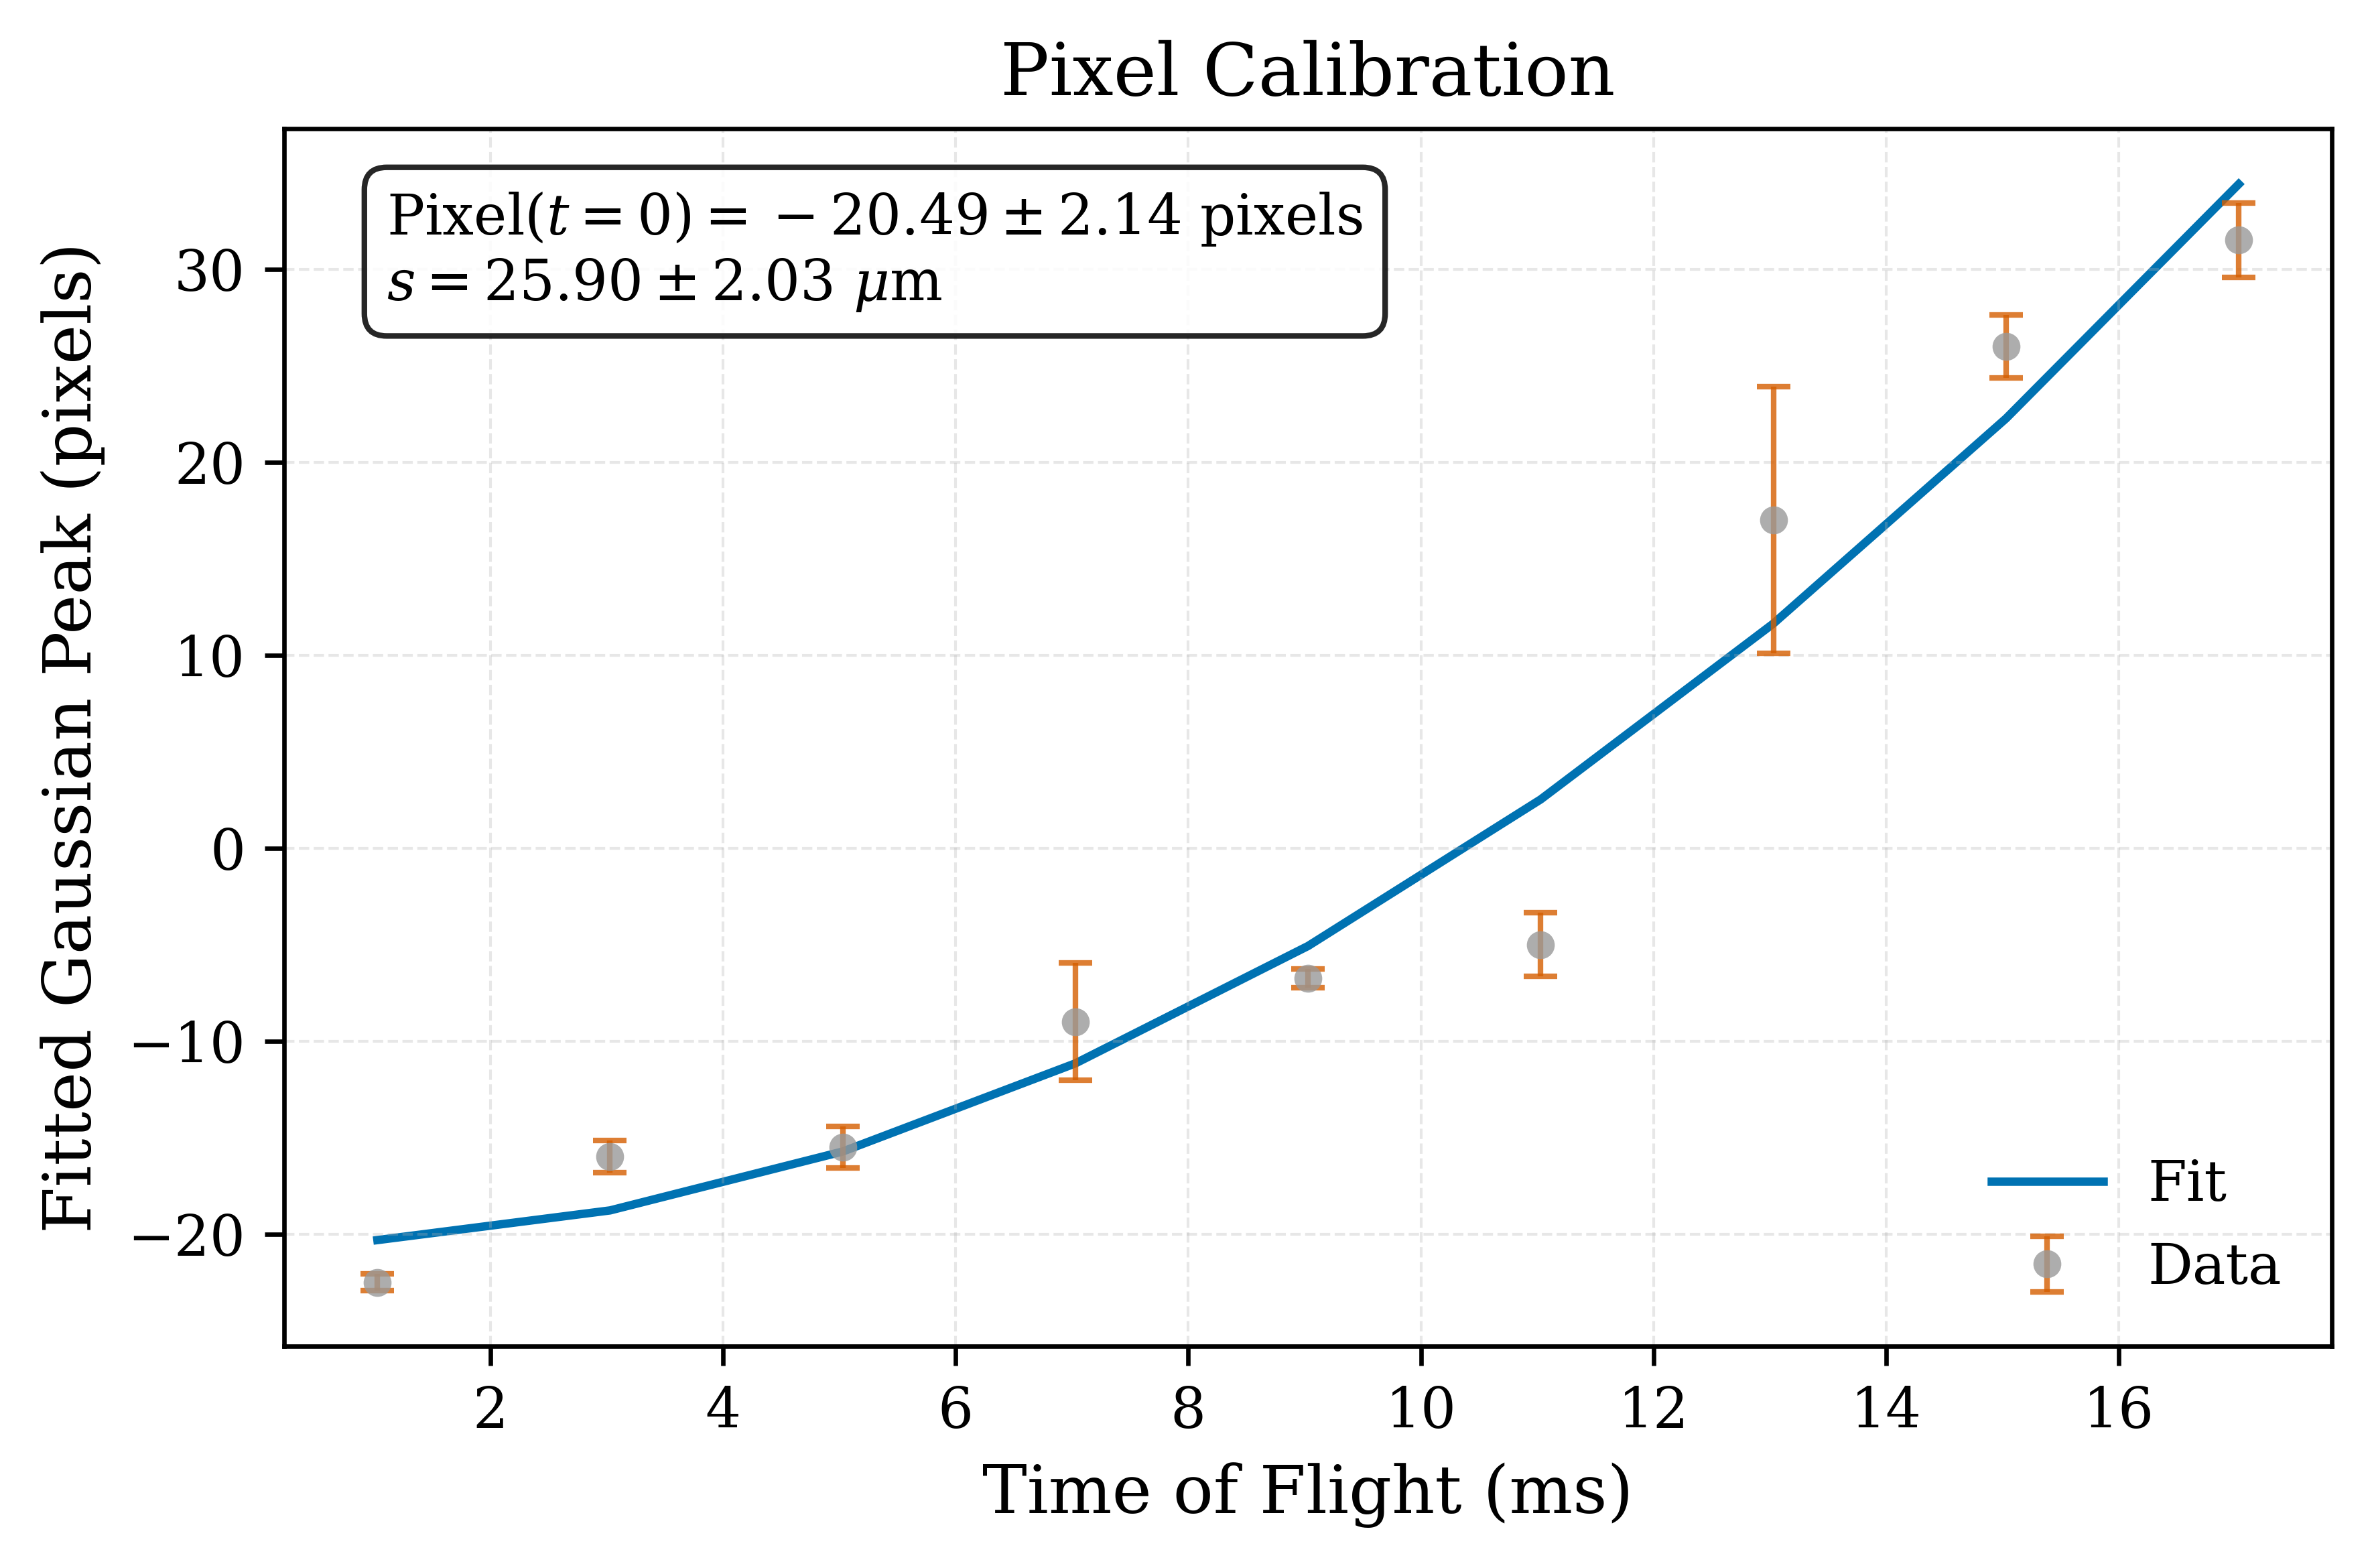

In [226]:
import matplotlib.pyplot as plt

# Global style settings (without LaTeX)
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",  # serif math font
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "errorbar.capsize": 3,
    }
)

# Create high-resolution figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)

# --- Fit Line ---
ax.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    color="#0072B2",  # Blue
    label="Fit",
    zorder=1,
)

# --- Data Points with Error Bars ---
ax.errorbar(
    t_data_sorted * 1e3,
    pixel_data_sorted,
    yerr=peakx_std,
    fmt="o",
    color="#999999",  # Light gray points
    ecolor="#D55E00",  # Reddish error bars
    markerfacecolor="#999999",
    markeredgecolor="none",
    alpha=0.8,
    markersize=5,
    linewidth=1,
    zorder=2,
    label="Data",
)

# --- Fit Text Annotation (Mathtext only) ---
fit_text = (
    r"$\mathrm{Pixel}(t{=}0) = "
    + f"{y0_fit:.2f} \pm {y0_err:.2f}"
    + r"\ \mathrm{pixels}$"
    + "\n"
    + r"$s = "
    + f"{s_fit * 1e6:.2f} \pm {s_err * 1e6:.2f}"
    + r"\ \mu\mathrm{m}$"
)

ax.text(
    0.05,
    0.95,
    fit_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white", edgecolor="black", boxstyle="round,pad=0.4", alpha=0.85
    ),
)

# --- Labels and Title ---
ax.set_xlabel("Time of Flight (ms)")
ax.set_ylabel("Fitted Gaussian Peak (pixels)")
ax.set_title("Pixel Calibration")

# --- Styling ---
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(frameon=False, loc="best")
plt.tight_layout()

# --- Show or Save ---
# plt.savefig("pixel_calibration.png", dpi=600, bbox_inches='tight')
plt.show()


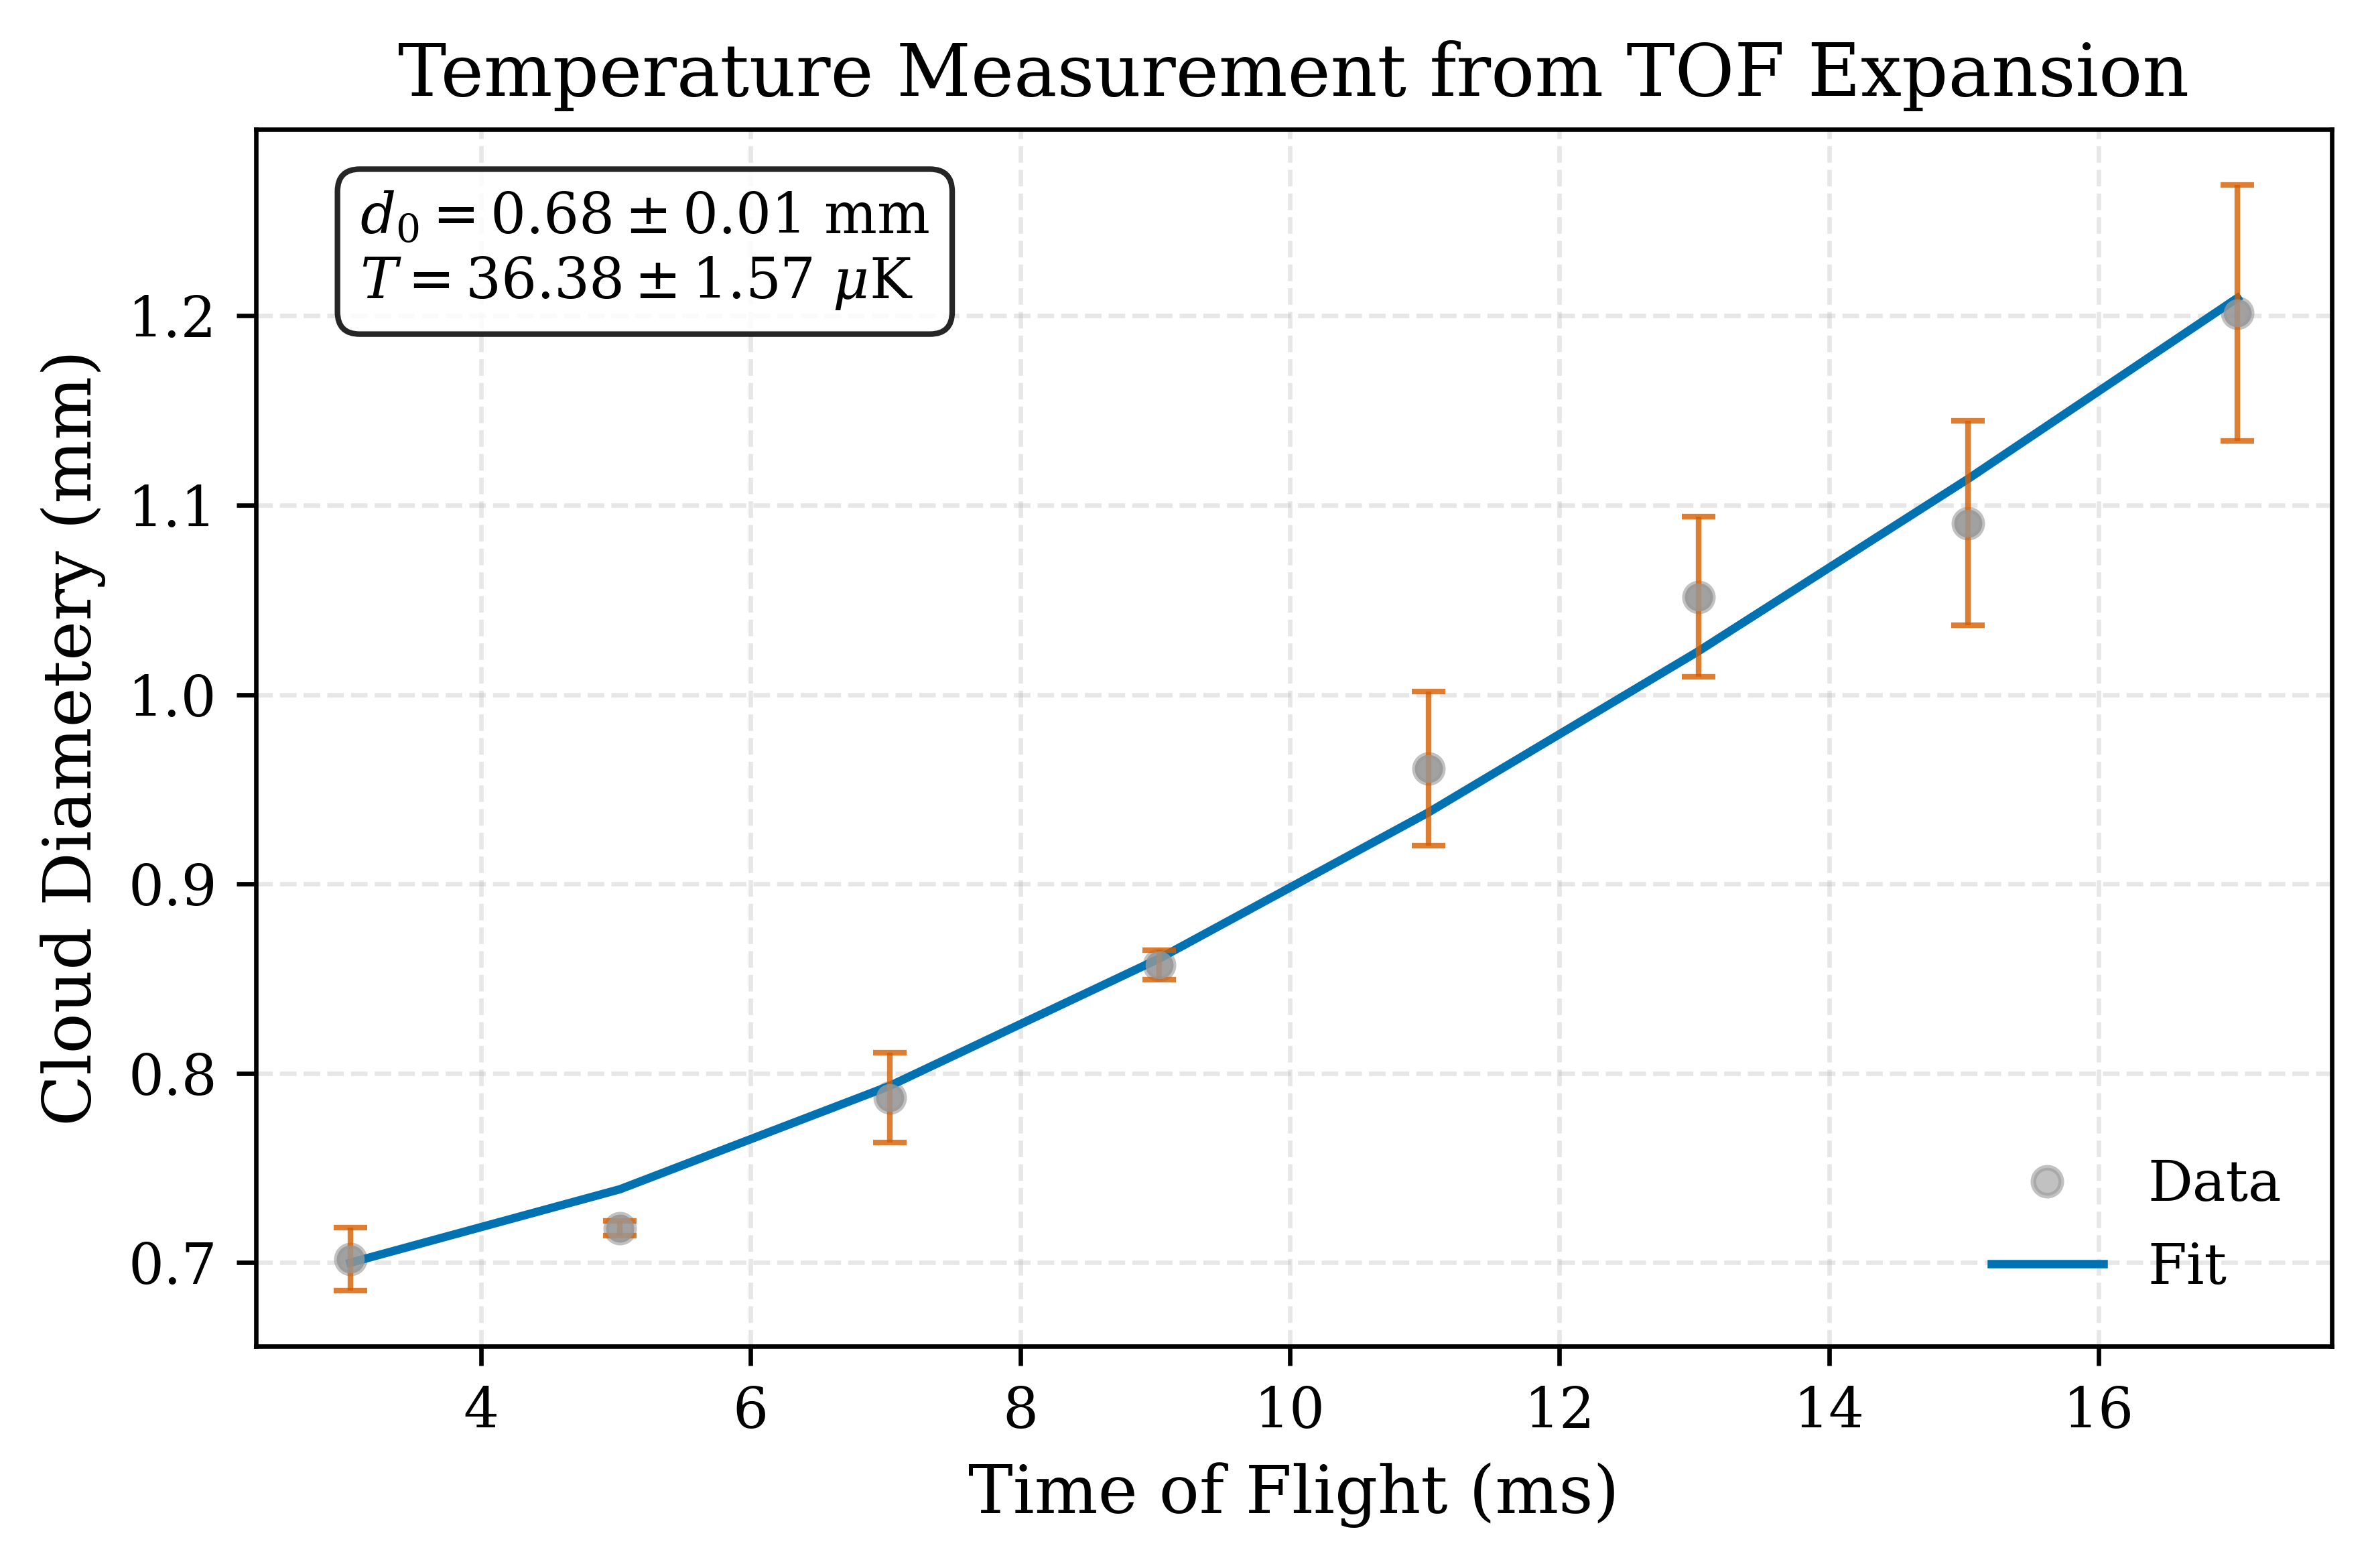

d₀ = 0.6769 ± 0.0135 mm
T  = 36.3767 ± 1.5661 μK
Final temperature: 36.3767 ± 27.3757 μK


In [227]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Data (replace with yours)
# ----------------------------




sy_mean = mean_std(Sy_set)[0]
sy_std = mean_std(Sy_set)[1]

physical_scale=24.83e-6  # µm/pixel from pixel calibration
sy_mean = [i * physical_scale for i in sy_mean]  # Convert to meters
sy_std = [i * physical_scale for i in sy_std]  # Convert to meters

d_data = np.array(sy_mean)  # Measured diameters (m)

# Sort data
t_data_sorted = np.sort(t_data)
d_data_sorted = d_data[np.argsort(t_data)]

#remove the first data point (optional)
t_data_sorted = t_data_sorted[1:]
d_data_sorted = d_data_sorted[1:]
sy_mean = sy_mean[1:]
sy_std = sy_std[1:]

# ----------------------------
# ⚙️ Physics constants
# ----------------------------
kB = 1.380649e-23  # J/K
m = 1.45e-25  # Mass of atom (kg)


# ----------------------------
# Model: d(t) = sqrt(d0^2 + (kB*T/m)*t^2)
# ----------------------------
def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)


# Fit parameters
p0 = [2e-3, 100e-6]  # Initial guess: [d0 (m), T (K)]
bounds = ([0, 0], [np.inf, np.inf])
popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)

d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

# ----------------------------
# 🎨 Plotting (Nature style)
# ----------------------------

# Plot style
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "errorbar.capsize": 3,
    }
)

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)

# --- Data Points ---
ax.plot(
    t_data_sorted * 1e3,
    d_data_sorted * 1e3,
    "o",
    color="#999999",
    markersize=5,
    alpha=0.6,
    label="Data",
)

# --- Fit Curve ---
ax.plot(
    t_data_sorted * 1e3, model(t_data_sorted, *popt) * 1e3, color="#0072B2", label="Fit"
)

# --- Fit Parameters Box ---
fit_text = (
    r"$d_0 = "
    + f"{d0_fit * 1e3:.2f} \pm {d0_err * 1e3:.2f}"
    + r"\ \mathrm{{mm}}$"
    + "\n"
    + r"$T = "
    + f"{T_fit * 1e6:.2f} \pm {T_err * 1e6:.2f}"
    + r"\ \mu\mathrm{{K}}$"
)

ax.text(
    0.05,
    0.95,
    fit_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white", edgecolor="black", boxstyle="round,pad=0.4", alpha=0.85
    ),
)

# --- Labels & Layout ---
ax.set_xlabel("Time of Flight (ms)")
ax.set_ylabel("Cloud Diametery (mm)")
ax.set_title("Temperature Measurement from TOF Expansion")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()


#multiply each element of sy_mean and sy_std with 1e3 to convert to mm
sy_mean = [i * 1e3 for i in sy_mean]
sy_std = [i * 1e3 for i in sy_std]

#error bars
ax.errorbar(
    t_data_sorted * 1e3,
    sy_mean,
    yerr=sy_std,
    fmt="o",
    color="#999999",  # Light gray points
    ecolor="#D55E00",  # Reddish error bars
    markerfacecolor="#999999",
    markeredgecolor="none",
    alpha=0.8,
    markersize=5,
    linewidth=1,
    zorder=2,
    label="Data",
)
plt.show()
# ----------------------------
# Final Output
# ----------------------------

print(f"d₀ = {d0_fit * 1e3:.4f} ± {d0_err * 1e3:.4f} mm")
print(f"T  = {T_fit * 1e6:.4f} ± {T_err * 1e6:.4f} μK")

# Pixel size calibration uncertainty
s = 28.19  # µm/pixel
delta_s = 10.59  # µm/pixel

delta_T_pixel = T_fit * 2 * (delta_s / s)
delta_T_total = np.sqrt(T_err**2 + delta_T_pixel**2)

print(f"Final temperature: {T_fit * 1e6:.4f} ± {delta_T_total * 1e6:.4f} μK")
